<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/Fashion_mnist_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8193 - loss: 0.5200 - val_accuracy: 0.8441 - val_loss: 0.4276
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8616 - loss: 0.3815 - val_accuracy: 0.8550 - val_loss: 0.3989
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8734 - loss: 0.3434 - val_accuracy: 0.8753 - val_loss: 0.3489
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8816 - loss: 0.3193 - val_accuracy: 0.8786 - val_loss: 0.3322
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8878 - loss: 0.2997 - val_accuracy: 0.8849 - val_loss: 0.3206
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8938 - loss: 0.2851 - val_accuracy: 0.8717 - val_loss: 0.3559
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8979 - loss: 0.2748 - val_accuracy: 0.8813 - val_loss: 0.3243
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9004 - loss: 0.2615 

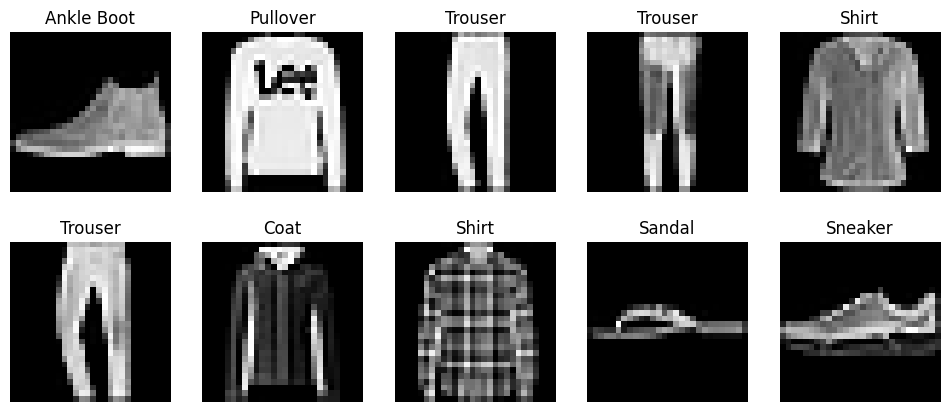

In [1]:
# Step 1 : Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Step 2 : Load Dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

# Step 3 : Normalize

X_train = X_train / 255.0
X_test = X_test / 255.0

# Fashion Labels

fashion_labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Step 4 : Build ANN

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 5 : Compile

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6 : Train

model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Step 7 : Evaluate

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy = {:.2f}%".format(accuracy*100))

# Step 8 : Prediction

prediction = model.predict(X_test)

predicted = np.argmax(prediction, axis=1)

print("\nFirst 10 Predictions\n")

for i in range(10):
    print("Predicted:",
          fashion_labels[predicted[i]],
          "| Actual:",
          fashion_labels[y_test[i]])

# Step 9 : Show Images

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(fashion_labels[predicted[i]])
    plt.axis("off")

plt.show()